# NSGA-II Multi-Objective Demo

This notebook runs NSGA-II on three classic multi-objective benchmarks:
- Schaffer N1 (1 variable, 2 objectives)
- ZDT1 (10 variables, 2 objectives)
- Kursawe (3 variables, 2 objectives)

It then plots the approximate Pareto fronts ($f_1$ vs $f_2$) for each case.

## 3D Pareto front (three objectives)

A final example adds a 3-objective DTLZ2 run and visualizes the Pareto
approximation in an interactive 3D Plotly scatter ($f_1$, $f_2$, $f_3$).

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Add the repo src directory to sys.path for local imports
repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
src_dir = os.path.join(repo_root, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from NSGA2 import nsga2_main
from ObjectiveFunction import ObjectiveFunction

In [2]:
def run_case(method, lb, ub, population, max_gen, seed):
    of = ObjectiveFunction(method=method)
    result = nsga2_main(
        of.func,
        lb=lb,
        ub=ub,
        population=population,
        max_gen=max_gen,
        seed=seed,
    )
    pareto_front = np.array(result["pareto_front"])
    return result, pareto_front

cases = [
    {
        "name": "Schaffer N1",
        "method": "schaffer_n1",
        "lb": [-10.0],
        "ub": [10.0],
        "population": 40,
        "max_gen": 40,
        "seed": 1,
    },
    {
        "name": "ZDT1 (n=10)",
        "method": "zdt1",
        "lb": [0.0] * 10,
        "ub": [1.0] * 10,
        "population": 80,
        "max_gen": 60,
        "seed": 2,
    },
    {
        "name": "Kursawe",
        "method": "kursawe",
        "lb": [-5.0] * 3,
        "ub": [5.0] * 3,
        "population": 60,
        "max_gen": 50,
        "seed": 3,
    },
]

results = []
for case in cases:
    result, pf = run_case(
        case["method"],
        case["lb"],
        case["ub"],
        case["population"],
        case["max_gen"],
        case["seed"],
    )
    results.append((case, result, pf))

for case, result, pf in results:
    print(f"{case['name']}: {len(pf)} Pareto points")
    if len(pf) > 0:
        print("  sample points:", pf[:5])
    print()

Schaffer N1: 40 Pareto points
  sample points: [[1.54156178e-06 4.00496793e+00]
 [4.00265503e+00 4.40428125e-07]
 [8.86265597e-01 1.12059839e+00]
 [2.02644435e+00 3.32314953e-01]
 [2.39042725e-01 2.28336289e+00]]

ZDT1 (n=10): 80 Pareto points
  sample points: [[9.95225415e-01 6.17261976e-03]
 [5.93116720e-11 1.01109816e+00]
 [4.58000352e-02 8.17836108e-01]
 [8.96288143e-02 7.03453276e-01]
 [1.14005998e-02 9.02388787e-01]]

Kursawe: 60 Pareto points
  sample points: [[-14.46225961 -11.61002684]
 [-19.91172089   0.08727061]
 [-19.08507444   0.04802586]
 [-17.03833412  -3.8782023 ]
 [-17.93383844  -3.85973938]]



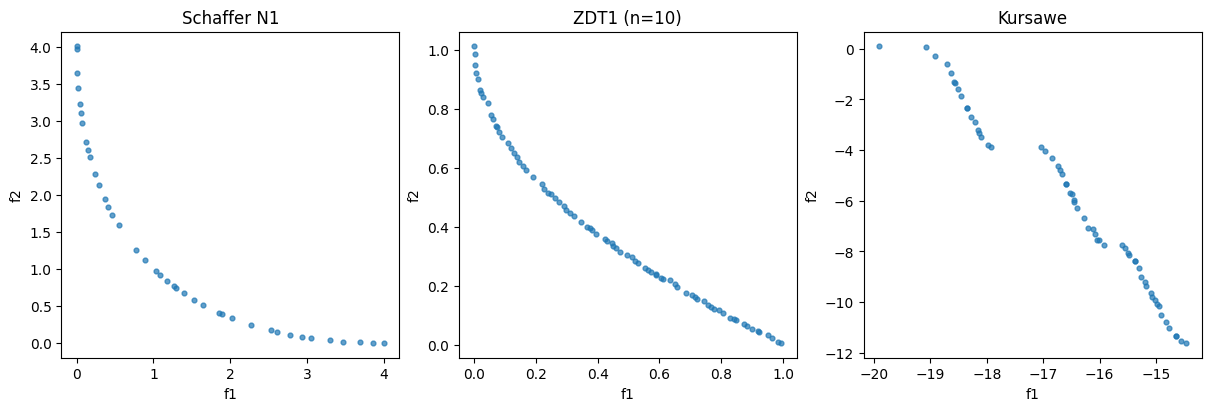

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

for ax, (case, result, pf) in zip(axes, results):
    ax.set_title(case["name"])
    ax.set_xlabel("f1")
    ax.set_ylabel("f2")
    if len(pf) > 0:
        ax.scatter(pf[:, 0], pf[:, 1], s=12, alpha=0.7)
    else:
        ax.text(0.5, 0.5, "No Pareto points", ha="center", va="center")

plt.show()

In [6]:
# 3D Pareto front example (DTLZ2, 3 objectives)
import plotly.graph_objects as go
import plotly.io as pio

try:
    import nbformat  # noqa: F401
    pio.renderers.default = "notebook_connected"
except Exception:
    # Fallback for environments without nbformat support
    pio.renderers.default = "browser"

def dtlz2(u):
    u = np.asarray(u)
    m = 3
    g = np.sum((u[m - 1:] - 0.5) ** 2)
    f1 = (1.0 + g) * np.cos(u[0] * np.pi / 2.0) * np.cos(u[1] * np.pi / 2.0)
    f2 = (1.0 + g) * np.cos(u[0] * np.pi / 2.0) * np.sin(u[1] * np.pi / 2.0)
    f3 = (1.0 + g) * np.sin(u[0] * np.pi / 2.0)
    return [f1, f2, f3]

dtlz2_result = nsga2_main(
    dtlz2,
    lb=[0.0] * 7,
    ub=[1.0] * 7,
    population=120,
    max_gen=80,
    seed=4,
)
pf3 = np.array(dtlz2_result["pareto_front"])

print(f"DTLZ2 (3 objectives): {len(pf3)} Pareto points")
if len(pf3) > 0:
    print("  sample points:", pf3[:5])

if len(pf3) > 0:
    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=pf3[:, 0],
                y=pf3[:, 1],
                z=pf3[:, 2],
                mode="markers",
                marker=dict(size=3, opacity=0.7),
            )
        ]
    )
    fig.update_layout(
        title="DTLZ2 Pareto (3 objectives)",
        scene=dict(
            xaxis_title="f1",
            yaxis_title="f2",
            zaxis_title="f3",
        ),
        margin=dict(l=0, r=0, b=0, t=40),
    )
    fig.show()
else:
    print("No Pareto points to plot.")

DTLZ2 (3 objectives): 120 Pareto points
  sample points: [[1.76334103e-07 3.46854004e-02 1.00972037e+00]
 [2.14267898e-06 1.87463665e-11 1.01099922e+00]
 [2.13617022e-01 9.84354228e-01 1.32824836e-09]
 [3.76804282e-04 1.00944297e+00 3.36342390e-02]
 [1.04779132e+00 3.41969166e-06 4.82242886e-03]]
